<a href="https://colab.research.google.com/github/danielruizm16/ComputationalMethods_2026_I/blob/main/Raíces/Raíces.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Raíces de Ecuaciones

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import fixed_point, bisect, newton, root_scalar, fsolve

## 1.
La velocidad $v$ de un cohete Saturn V en vuelo vertical cerca de la superficie de la Tierra puede aproximarse mediante:
$$v = u \ln \left( \frac{M_0}{M_0 - \dot{m}t} \right) - gt$$
donde:
- $ u = 2510 \, \text{m/s} $ = velocidad de escape relativa al cohete
- $ M_0 = 2.8 \times 10^6 \, \text{kg} $ = masa del cohete en el despegue
- $ \dot{m} = 13.3 \times 10^3 \, \text{kg/s} $ = tasa de consumo de combustible
- $ g = 9.81 \, \text{m/s}^2 $ = aceleración gravitacional
- $t$ = tiempo medido desde el despegue

Determine el tiempo en el que el cohete alcanza la velocidad del sonido ($335 \, \text{m/s}$)

In [ ]:
def bisection_method(f, a, b, tol=1e-6, max_iter=100):
    """
    Encuentra una raíz de una función usando el método de bisección.
    
    Parámetros:
    f : función
        La función para la cual se desea encontrar la raíz. Debe ser continua en [a, b].
    a : float
        Extremo izquierdo del intervalo inicial.
    b : float
        Extremo derecho del intervalo inicial.
    tol : float, opcional
        Tolerancia para la convergencia (por defecto: 1e-6). El algoritmo se detiene cuando |f(c)| < tol.
    max_iter : int, opcional
        Número máximo de iteraciones (por defecto: 100).
    
    Retorna:
    c : float
        La raíz aproximada de la función.
    i+1 : int
        El número de iteraciones realizadas.
    """
    if f(a) * f(b) >= 0:
        raise ValueError("La función no cambia de signo en el intervalo [a, b].")
    
    for i in range(max_iter):
        c = (a + b) / 2
        
        if abs(f(c)) < tol:
            return c, i + 1
        elif f(a) * f(c) < 0:
            b = c
        else:
            a = c
            
    raise RuntimeError(f'Raíz no encontrada después de {max_iter} iteraciones')

In [40]:
# Parámetros del problema
u = 2510          # m/s
M0 = 2.8e6        # kg
m_dot = 13.3e3    # kg/s
g = 9.81          # m/s²
v_sound = 335     # m/s

# Función v(t)
def v(t):
    return u * np.log(M0 / (M0 - m_dot * t)) - g * t

# Función f(t) = v(t) - v_sound = 0
def f(t):
    return v(t) - v_sound

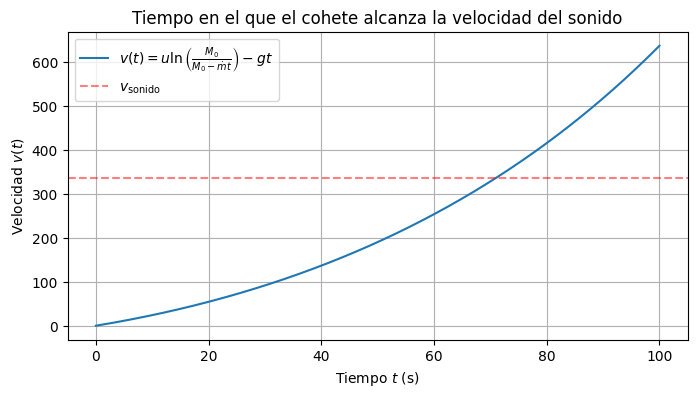

In [41]:
# Rango de Tiempos
t_values = np.linspace(0, 100, 500)
v_values = v(t_values)

# Plot
plt.figure(figsize=(8, 4))
plt.plot(t_values, v_values, label=r'$v(t) = u \ln\left(\frac{M_0}{M_0 - \dot{m}t}\right) - gt $')
plt.axhline(v_sound, color='red', linestyle='--', alpha=0.5, label=r'$v_{\text{sonido}}$')
plt.xlabel('Tiempo $t$ (s)')
plt.ylabel('Velocidad $v(t)$')
plt.title('Tiempo en el que el cohete alcanza la velocidad del sonido')
plt.grid()
plt.legend()
plt.show()

In [42]:
t_biseccion = bisection_method(f, 60, 80)[0]
print(f"Solucion con bisección: t ≈ {t_biseccion:.6f} s")

Solucion con bisección: t ≈ 70.877972 s


## 2.

La energía libre de Gibbs para 1 mol de hidrógeno a una temperatura $T$ está dada por:

$$G = -RT \ln \left[ \left( \frac{T}{T_0} \right)^{5/2} \right]$$

donde:
- $R = 8.314 \, \text{J/K}$ es la constante de los gases.  
- $T_0 = 4.444 \, \text{J/K}$ es una constante de referencia. 

Determine la temperatura $T$ a la cual $G = -10^5 \, \text{J}$ utilizando el método de bisección y el método de punto fijo.

In [43]:
# Constantes
R = 8.314  # J/K
T0 = 4.444  # J/K
G_target = -1e5  # J

In [44]:
# Definimos la función G(T)
def G(T):
    return -R * T * np.log((T / T0)**(5/2))

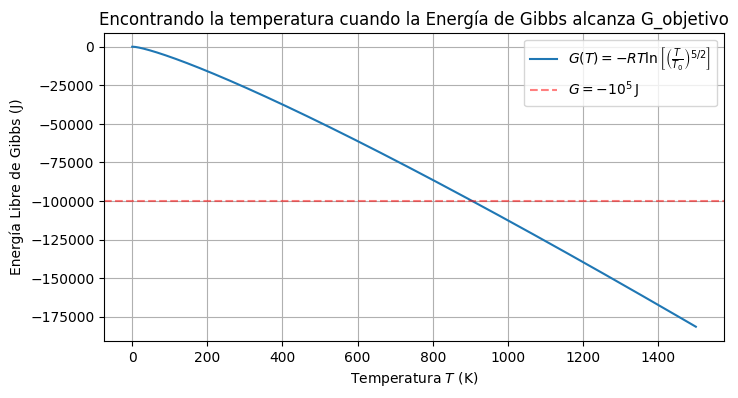

In [45]:
T_vals = np.linspace(0.1, 1500, 1000)
G_vals = G(T_vals)
plt.figure(figsize=(8, 4))
plt.plot(T_vals, G_vals, label=r'$G(T) = -RT \ln \left[ \left( \frac{T}{T_0} \right)^{5/2} \right]$')
plt.axhline(G_target, color='red', linestyle='--', alpha=0.5, label=r'$ G = -10^5 \, \text{J}$')
plt.xlabel('Temperatura $T$ (K)')
plt.ylabel('Energía Libre de Gibbs (J)')
plt.title('Encontrando la temperatura cuando la Energía de Gibbs alcanza G_objetivo')
plt.grid()
plt.legend()
plt.show()

In [46]:
# Definimos la función f(T) = G(T) - G_objetivo = 0 para el método de bisección
def f(T):
    return G(T) - G_target

# Resolver
T_solucion_biseccion, _ = bisection_method(f, 800, 1000)
print(f"La temperatura T es: {T_solucion_biseccion:.2f} K")

La temperatura T es: 904.97 K


In [47]:
# Método de Punto Fijo
def fixed_point_method(g, x0, tol=1e-6, max_iter=200):
    """
    Encuentra el punto fijo de la función g usando el método de Punto Fijo
    
    Parámetros:
    g: función tal que x = g(x)
    x0: aproximación inicial
    tol: tolerancia para la convergencia
    max_iter: número máximo de iteraciones
    
    Retorna:
    x_new: punto fijo estimado
    """
    x = x0
    for i in range(max_iter):
        x_new = g(x)
        error = abs(x_new - x)
        if error < tol:
            return x_new
        x = x_new
    return x

En nuestro problema, hay dos formas diferentes de llegar a $T=g(T)$ desde $f(T)=0$.
$$G_{target} = -RT \ln \left[ \left( \frac{T}{T_0} \right)^{5/2} \right]$$
$$ f(T)=G_{target}+RT \ln \left[ \left( \frac{T}{T_0} \right)^{5/2} \right]=0$$

### Primera forma:
$$T = T_0 e^{\frac{-2G_{target}}{5RT}}=g_1(T)$$

In [48]:
# Definimos la opción 1 para la función g(T)
def g_1(T):
    return T0 * np.exp(-2 * G_target / (5 * R * T))

# Resolver
T_solucion_punto_fijo = fixed_point_method(g_1, 900)
print(f"La temperatura T es: {T_solucion_punto_fijo:.2f} K")

La temperatura T es: 4.44 K


/tmp/ipykernel_50263/2985223171.py:3: RuntimeWarning: overflow encountered in exp
  return T0 * np.exp(-2 * G_target / (5 * R * T))


Esto sucede porque $|g'(T)| > 1$ cerca de la raíz, violando la condición de convergencia.

$$
g_1(T) = T_0 e^{-\frac{2G_{target}}{5RT}}
$$

$$
g_1'(T) = T_0 \exp \left(-\frac{2G_{target}}{5RT} \right) \cdot \left(\frac{2G_{target}}{5RT^2} \right)
$$

En el punto fijo $T^*$, se cumple que $T_0 \exp \left(-\frac{2G_{target}}{5RT^*} \right) = T^*$, por lo tanto:

$$
g_1'(T^*) = T_0 \exp \left(-\frac{2G_{target}}{5RT^*} \right) \cdot \left(\frac{2G_{target}}{5R{T^{*}}^{2}} \right)= T^* \cdot \left(\frac{2G_{target}}{5R{T^{*}}^{2}} \right) = \frac{2G_{target}}{5RT^{*}}
$$

A partir de $T^* \ln\left( \frac{T^*}{T_0} \right) =-\frac{2G_{target}}{5R}$, se tiene que $\frac{2G_{target}}{5RT^{*}} = -\ln\left( \frac{T^*}{T_0} \right) $, por lo cual:

$$
|g_1'(T^*)| = |-\ln\left( \frac{T^*}{T_0} \right)| = \ln\left( \frac{T^*}{T_0} \right)
$$

Dado que $ \frac{T^*}{T_0} \gg 1 $, entonces $|g_1'(T^*)| > 1$ $\Rightarrow$ diverge.

### Segunda forma:
$$T = \frac{G_{target}}{R \ln \left[ \left( \frac{T}{T_0} \right)^{5/2} \right]}=g_2(T)$$

In [49]:
# Definimos la opción 2 para la función g(T)
def g_2(T):
    return -G_target / (R * np.log((T / T0)**(5/2)))

# Resolver
T_solucion_punto_fijo = fixed_point_method(g_2, 900)
print(f"La temperatura T es: {T_solucion_punto_fijo:.2f} K")

La temperatura T es: 904.97 K


Esto sucede porque $|g^\prime (T)| < 1$ cerca de la raíz, cumpliendo con la condición de convergencia.

$$
g_2(T) = \frac{G_{target}}{R \ln \left[ \left( \frac{T}{T_0} \right)^{5/2} \right]}= \frac{2G_{target}}{5 R \ln \left[ \left( \frac{T}{T_0} \right) \right]}
$$

$$
g_2'(T) =- \frac{2 G_{target}}{\left[5R \ln  \left( \frac{T}{T_0} \right) \right]^2} \cdot \frac{5R}{T}=- \frac{2 G_{target}}{5R \left[ \ln  \left( \frac{T}{T_0} \right) \right]^2} \cdot \frac{1}{T}
$$

En el punto fijo $T^*$, se cumple que $\frac{2G_{target}}{5 R} = T^* \ln\left( \frac{T^*}{T_0} \right)$, por lo tanto:

$$
g_2'(T^*) = - \frac{T^* \ln\left( \frac{T^*}{T_0} \right)}{\left[ \ln\left( \frac{T^*}{T_0} \right) \right]^2 \, T^*} = - \frac{1}{\ln\left( \frac{T^*}{T_0} \right)}
$$

De este modo:

$$
|g_2'(T^*)| = \frac{1}{\ln\left( \frac{T^*}{T_0} \right)}
$$

Dado que $\ln\left( \frac{T^*}{T_0} \right) > 1 $, entonces $|g_2'(T^*)| < 1$ $\Rightarrow$ converge.

## 3. Método de Regula Falsi 

El método de Regula Falsi es una modificación del método de bisección. Basado en los siguientes pasos, escribe una función que calcule la raíz de una función con este método.

### Pasos

1. **Inicialización:**
    Comienza con un intervalo $[a, b]$ donde $f(a)$ y $f(b)$ tengan signos opuestos.

    Esto garantiza que hay al menos una raíz en el intervalo (por el Teorema del Valor Intermedio).

2. **Cálculo del punto de intersección:**
    En lugar de tomar el punto medio como en el método de bisección, calcula un punto $c$ usando la siguiente fórmula:
    $$c = \frac{a \cdot f(b) - b \cdot f(a)}{f(b) - f(a)}$$
    Esta fórmula representa la intersección de la línea que conecta los puntos $(a, f(a))$ y $(b, f(b))$ con el eje x.

3. **Evaluación y actualización del intervalo:**

Evalúa $f(c)$.

- Si $f(c) = 0$ (o es menor que una tolerancia establecida), entonces $c$ es la raíz.

- Si $f(c)$ tiene el mismo signo que $f(a)$, actualiza $a = c$.

- Si $f(c)$ tiene el mismo signo que $f(b)$, actualiza $b = c$.

4. **Iteración:**

Repite los pasos 2 y 3 hasta que se cumpla un criterio de parada (por ejemplo, $|f(c)| < \text{tolerancia}$ o se alcance un número máximo de iteraciones).

In [50]:
def regula_falsi(f, a, b, tol=1e-6, max_iter=100):
    """
    Encuentra la raíz de la función f usando el método de Regula Falsi
    
    Parámetros:
    f: función a la que se le encontrará la raíz
    a, b: extremos del intervalo [a, b]
    tol: tolerancia para la convergencia
    max_iter: número máximo de iteraciones
    
    Retorna:
    raiz: raíz estimada
    """
    
    # Verificar si el intervalo inicial es válido
    if f(a) * f(b) >= 0:
        raise ValueError("f(a) y f(b) deben tener signos opuestos")
    
    for i in range(max_iter):
        # Calcular el punto de intersección
        c = (a * f(b) - b * f(a)) / (f(b) - f(a))
        fc = f(c)
        
        # Verificar convergencia
        if abs(fc) < tol:
            return c
        
        # Actualizar intervalo
        if f(a) * fc < 0:
            b = c
        else:
            a = c
    print(f"Máximo de iteraciones alcanzado ({max_iter})")
    return c

In [51]:
# Función de prueba: f(x) = x^2 - 4
funcion_prueba = lambda x: x**2 - 4

# Prueba para la raíz positiva (x = 2)
print("Encontrando la raíz positiva (x = 2):")
a, b = 1, 3  # Intervalo que contiene la raíz x = 2
raiz1 = regula_falsi(funcion_prueba, a, b, tol=1e-6)
print(f"Raíz encontrada: {raiz1:.8f}")
print(f"Raíz verdadera: 2.00000000")
print(f"Error absoluto: {abs(raiz1 - 2):.2e}\n")

# Prueba para la raíz negativa (x = -2)
print("Encontrando la raíz negativa (x = -2):")
a, b = -3, -1  # Intervalo que contiene la raíz x = -2
raiz2 = regula_falsi(funcion_prueba, a, b, tol=1e-6)
print(f"Raíz encontrada: {raiz2:.8f}")
print(f"Raíz verdadera: -2.00000000")
print(f"Error absoluto: {abs(raiz2 - (-2)):.2e}\n")

Encontrando la raíz positiva (x = 2):
Raíz encontrada: 1.99999986
Raíz verdadera: 2.00000000
Error absoluto: 1.37e-07

Encontrando la raíz negativa (x = -2):
Raíz encontrada: -1.99999986
Raíz verdadera: -2.00000000
Error absoluto: 1.37e-07



# 4.

Un objeto que cae verticalmente a través del aire está sujeto a la resistencia viscosa además de la fuerza de gravedad. Suponga que un objeto con masa $m$ se deja caer desde una altura $s_0$ y que su altura después de $t$ segundos está dada por:

$$s(t) = s_0 - \frac{mg}{k}t + \frac{m^2 g}{k^2}(1 - e^{-kt/m})$$

donde $g = 9.8 \, \text{m/s}^2$ y $k$ representa el coeficiente de resistencia del aire en $\text{kg/s}$. Suponga $s_0 = 91.44 \, \text{m}$, $m = 0.11 \, \text{kg}$ y $k = 0.045 \, \text{kg/s}$. Encuentre, con una precisión de 0.01 s, el tiempo que tarda este objeto en chocar contra el suelo.

In [52]:
def newton_method(f, df, x0, tol=1e-6, max_iter=100):
    """
    Encuentra la raíz de la función f usando el método de Newton-Raphson
    
    Parámetros:
    f: función a la que se le encontrará la raíz
    df: derivada de la función f
    x0: aproximación inicial
    tol: tolerancia para la convergencia
    max_iter: número máximo de iteraciones
    
    Retorna:
    x: raíz estimada
    """
    x = x0
    for i in range(max_iter):
        fx = f(x)
        dfx = df(x)
        
        if dfx == 0:  # Evitar división por cero
            raise ValueError("Derivada igual a cero")
        
        x_new = x - fx / dfx
        error = abs(x_new - x)
        
        if error < tol:
            return x_new

        x = x_new
    return x

In [53]:
# Parámetros
s0 = 91.44  # pies
m = 0.11 # lb
k = 0.045   # lb-s/pie
g = 9.8 # pies/s^2

In [54]:
# Definir la función de posición s(t)
def s(t):
    return s0 - (m*g/k)*t + (m**2 * g / k**2) * (1 - np.exp(-k*t/m))

# Definir la derivada de s(t) (función de velocidad)
def ds_dt(t):
    return - (m*g/k) + (m*g/k) * np.exp(-k*t/m)

In [55]:
# Hacer una aproximación inicial - sin resistencia del aire sería t = sqrt(2*s0/g)
t_inicial = np.sqrt(2 * s0 / g) 

# Usar Newton-Raphson para encontrar la raíz
t_solucion = newton_method(s, ds_dt, t_inicial, tol=0.01)

print(f"Tiempo para impactar el suelo: {t_solucion:.3f} s")

Tiempo para impactar el suelo: 6.056 s


## 5
¿Para qué ángulo el área de un segmento circular es igual a la cuarta parte del área del círculo?

- Demuestre que la expresión que permite resolver este problema es:

$$
\theta - \sin \theta = \frac{\pi}{2}
$$

- Construya una gráfica para $\theta$. ¿Alrededor de qué valor se encuentra la solución?

- Utilice el método de bisección, el método de punto fijo, el método de Newton y el método de la secante para verificar la solución estimada en la parte anterior (para esta parte, se recomienda utilizar un `dataframe`).

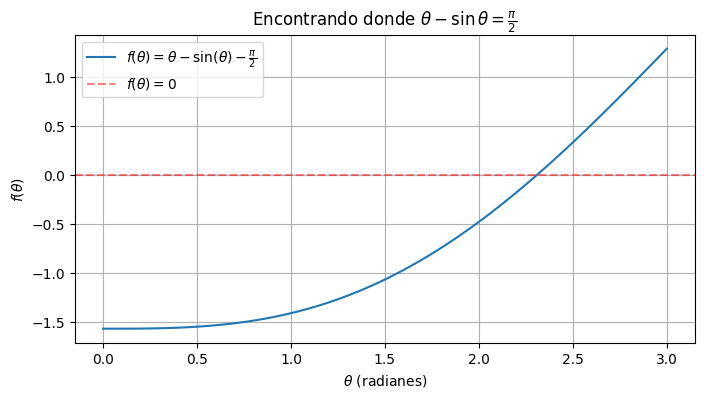

In [56]:
# Definir la función f
def f(theta):
    return theta - np.sin(theta) - np.pi/2

# Rango de theta para la gráfica
theta = np.linspace(0, 3, 500)
y = f(theta)

# Gráfica para estimar la solución
plt.figure(figsize=(8, 4))
plt.plot(theta, y, label=r'$f(\theta) = \theta - \sin(\theta) - \frac{\pi}{2}$')
plt.axhline(0, color='red', linestyle='--', alpha=0.5, label=r'$f(\theta) =0$')
plt.xlabel(r'$\theta$ (radianes)')
plt.ylabel(r'$f(\theta)$')
plt.title(r'Encontrando donde $\theta - \sin \theta = \frac{\pi}{2}$')
plt.grid(True)
plt.legend()
plt.show()

In [57]:
# Aplicar bisección en [2, 2.5]
theta_biseccion = bisection_method(f, 2, 2.5)[0]
print(f"Solución con bisección: θ ≈ {theta_biseccion:.6f} radianes")

Solución con bisección: θ ≈ 2.309881 radianes


In [58]:
# Definir la función g para el método de punto fijo
def g(theta):
    return np.sin(theta) + np.pi/2

# Punto Fijo con un ángulo inicial = 2.3
theta_punto_fijo = fixed_point_method(g, 2.3)
print(f"Solución con punto fijo: θ ≈ {theta_punto_fijo:.6f} radianes")

Solución con punto fijo: θ ≈ 2.309881 radianes


In [59]:
# Derivada para el método de Newton-Raphson
def df(theta):
    return 1 - np.cos(theta)

# Newton con un ángulo inicial = 2.3
theta_newton = newton_method(f, df, 2.3)
print(f"Solución con Newton: θ ≈ {theta_newton:.6f} radianes")

Solución con Newton: θ ≈ 2.309881 radianes


In [60]:
# Método de la Secante
def secant_method(f, x0, x1, tol=1e-6, max_iter=100):
    """
    Encuentra la raíz de la función f usando el método de la Secante
    
    Parámetros:
    f: función a la que se le encontrará la raíz
    x0, x1: dos aproximaciones iniciales
    tol: tolerancia para la convergencia
    max_iter: número máximo de iteraciones
    
    Retorna:
    x: raíz estimada
    """
    for i in range(max_iter):
        f0, f1 = f(x0), f(x1)
        
        if f1 - f0 == 0:  # Evitar división por cero
            raise ValueError("Denominador igual a cero")
        
        x2 = x1 - f1 * (x1 - x0) / (f1 - f0)
        error = abs(x2 - x1)
        
        if error < tol:
            return x2
        
        x0, x1 = x1, x2
    
    return x2

theta_secante = secant_method(f, 2, 2.5)
print(f"Solución con secante: θ ≈ {theta_secante:.6f} radianes")


Solución con secante: θ ≈ 2.309881 radianes


In [61]:
resultados = pd.DataFrame({
    "Método": ["Bisección", "Punto Fijo", "Newton", "Secante"],
    "θ (rad)": [theta_biseccion, theta_punto_fijo, theta_newton, theta_secante],
    "Error Relativo": [
        abs(theta_biseccion - theta_newton) / theta_newton,
        abs(theta_punto_fijo - theta_newton) / theta_newton,
        0,  # Newton es la referencia
        abs(theta_secante - theta_newton) / theta_newton
    ]
})

resultados

,Método,θ (rad),Error Relativo
0,Bisección,2.309881,1.080934e-07
1,Punto Fijo,2.309881,1.473827e-07
2,Newton,2.309881,0.000000e+00
3,Secante,2.309881,0.000000e+00


### Usando Scipy

In [62]:
raiz_b = bisect(f, 2, 2.5, xtol=1e-6)  # Bisección
raiz_n = newton(f, 2.2, fprime=df, tol=1e-6)  # Newton-Raphson
raiz_f = fixed_point(g, 2.2, xtol=1e-6)  # Punto Fijo
raiz_r = root_scalar(f, x0=2.2, x1=2.3, method='secant')  # Secante
raiz_fsolve = fsolve(f, 2)[0]  # fsolve

print(f'Raíz con método de bisección {raiz_b}')
print(f'Raíz con método de punto fijo {raiz_f}')
print(f'Raíz con método de Newton-Raphson {raiz_n}')
print(f'Raíz con método de la secante {raiz_r.root}')
print(f'Raíz con método fsolve {raiz_fsolve}')

Raíz con método de bisección 2.309882164001465
Raíz con método de punto fijo 2.3098814600100286
Raíz con método de Newton-Raphson 2.309881460010057
Raíz con método de la secante 2.309881460010058
Raíz con método fsolve 2.309881460010033
